# Tutorial 2.2: Simulation of Random Incomplete Registration in Human Lymph Node

This tutorial simulates random incomplete registration in paired human lymph node RNA-ADT data. RNA remains complete, whereas ADT is made unavailable at 50% of locations sampled across the entire tissue section. The resulting target-unregistered locations form a spatially dispersed and fragmented pattern, modelling non-contiguous target-modality loss.


In [1]:
from pathlib import Path

import scanpy as sc
import PRISM
from PRISM import (compute_similarity_prior, plot_per_protein_correlations, plot_prism_imputation_spatial,
                   preprocess_omics, prism_eval_and_save, run_clustering_eval_plot, select_best_device,
                   set_prism_plot_style, set_seed, simulate_missing_sliding)
set_prism_plot_style()

DEVICE = select_best_device()
RANDOM_SEED = 2024
set_seed(RANDOM_SEED)

In [2]:
# Load data and set up paths
Slice_ID = "S1"

DATASET_DIR = Path("Datasets") / "human lymphoid organs" / "lymph" / Slice_ID
SOURCE_H5AD = DATASET_DIR / "adata_RNA.h5ad"    
TARGET_H5AD = DATASET_DIR / "adata_ADT.h5ad"
RESULTS_DIR = Path("Results") / "Tutorial2_2_human_lymph_node"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PRIOR_PATH = RESULTS_DIR / f"{Slice_ID}_lymph_AOT.npz"
RUN_PREFIX = f"{Slice_ID}_lymph"

adata_source = sc.read_h5ad(SOURCE_H5AD)
adata_target = sc.read_h5ad(TARGET_H5AD)
adata_source.var_names_make_unique()
adata_target.var_names_make_unique()

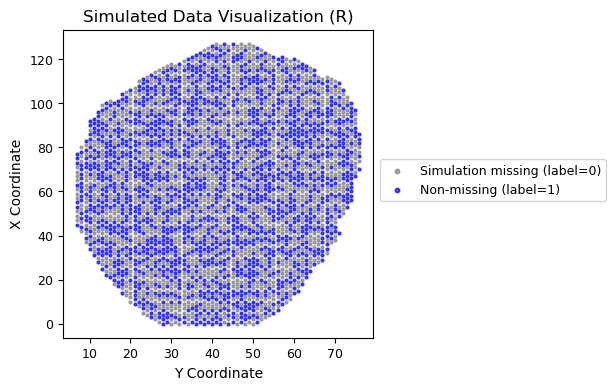

ADT missing cells: 1742/3484


In [3]:
# Simulate global random missingness in ADT
missing_indices = simulate_missing_sliding(adata_target, spatial_key="spatial", direction="R", missing_width=0.5, 
                                           step_ratio=0.1, step_id=0, label_key="missing", lock_at_end=True,
                                           point_size=4, plot=True, figsize=(4, 4))

print(f"ADT missing cells: {len(missing_indices)}/{adata_target.n_obs}")

In [4]:
# Preprocessing source (RNA) and target (ADT) modalities
adata_source, _ = preprocess_omics(adata_source, modality="RNA", missing_key="missing", min_cells=10,
                                   hvgs=3000, data_role="source", compute_pca=False, save_raw_eval=False)

adata_target, _ = preprocess_omics(adata_target, modality="ADT", missing_key="missing", data_role="target",
                                   compute_pca=False, save_log_layer=False, save_raw_eval=True)

print("RNA shape after preprocessing:", adata_source.shape)
print("ADT shape after preprocessing:", adata_target.shape)

RNA shape after preprocessing: (3484, 3000)
ADT shape after preprocessing: (3484, 31)


In [5]:
# Constructing the RNA similarity prior
distance_matrix, prior_metrics = compute_similarity_prior(adata_source, adata_target, PRIOR_PATH, device=DEVICE,
                                                          covet_k_spatial=6, covet_gene_num=64, spatial_key="spatial", 
                                                          missing_key="missing", store_neighbor_index=True)

Step 1: src COVET
Using the top 64 genes from the pre-calculated HVG ranking for COVET
Computing COVET using 64 genes
Using expression data from layer 'log'
Calculating covariance matrices for all cells/spots
Computing matrix square root.
[COVET | auto missing-aware mode]
Original n_obs : 3484
Reference n_obs: 3484
has missing    : False
missing cells  : 0
observed cells : 3484
k_spatial used     : 6
batch_key used     : -1
COVET shape        : (3484, 64, 64)
COVET_SQRT shape   : (3484, 64, 64)
Number of CovGenes : 64

Step 2: src AOT
[AOT] representation=full COVET_SQRT flatten
[AOT] n=3484, d=4096, k_env=3483, backend=torch
[AOT] distances stored are squared Euclidean/Frobenius distances.
[AOT/torch] device=cuda:7
[AOT/torch] processed 3484/3484
[AOT] saved adata.obsp['aot_distances_ref'] shape=(3484, 3484), nnz=12134772
[AOT | auto missing-aware mode]
Reference AOT shape      : (3484, 3484)
Reference AOT nnz        : 12134772
Original-space AOT shape : (3484, 3484)
Original-space AO

------Calculating spatial graph...
The graph contains 13638 edges, 3484 cells.
3.9145 neighbors per cell on average.


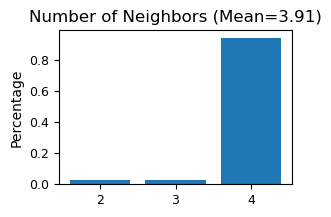

------Calculating spatial graph...
The graph contains 13638 edges, 3484 cells.
3.9145 neighbors per cell on average.


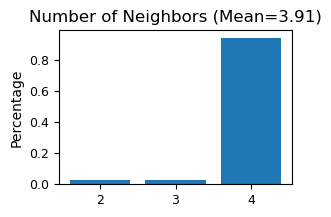

In [6]:
# Constructing spatial graphs
PRISM.Cal_Spatial_Net(adata_source, rad_cutoff=1.5)
PRISM.Stats_Spatial_Net(adata_source)
PRISM.Cal_Spatial_Net(adata_target, rad_cutoff=1.5)
PRISM.Stats_Spatial_Net(adata_target)

In [7]:
# Train PRISM
adata_source_out, adata_target_out = PRISM.train_PRISM(adata_source, adata_target, distance_matrix, 
                                                       k_top=5, n_epochs=1000, lr=1e-3, 
                                                       output_dir=str(RESULTS_DIR), file_prefix=RUN_PREFIX,
                                                       device=DEVICE, patience=20, min_epochs=50,
                                                       center_drop_rate=0.1, noise=0.0,
                                                       load_model_path=False, interaction_pca=True)

Similarity prior ready: 3484 cells, 5 observed neighbors per cell.



>>> Early stopping at epoch 286.
PRISM training and inference complete: S1_lymph


fitting ...
  |======================================================================| 100%
Domain clustering metrics: {'embedding': 'PRISM_emb', 'cluster_key': 'PRISM_mclust', 'AMI': 0.3890, 'V_measure': 0.3930, 'Mutual_info': 0.7315, 'Homogeneity': 0.4234, 'NMI': 0.3930, 'ARI': 0.2463}


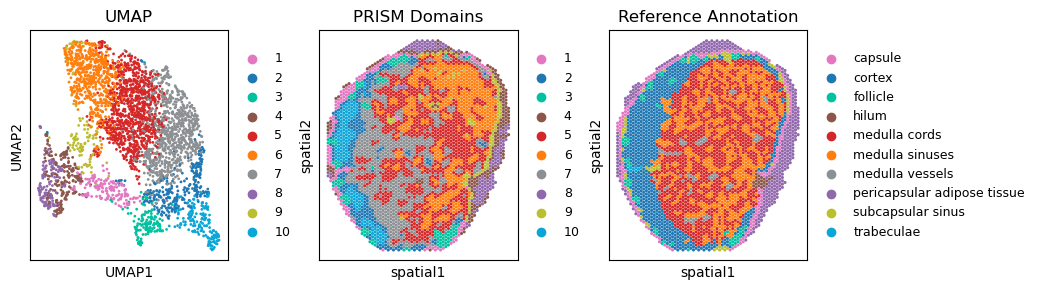

In [12]:
# Task 1: Spatial-domain identification
adata_clustered, domain_metrics = run_clustering_eval_plot(adata_source_out, emb_key="PRISM_emb", label_key="final_annot",
                                                           cluster_key="PRISM_mclust", n_clusters=10, s=20, use_pca=True,
                                                           align_labels=True, aligned_key="PRISM_mclust_domain",
                                                           dataset_name="lymph")

Imputation metrics (mean +/- s.d.): PCC=0.7121 +/- 0.1550, SPCC=0.6854 +/- 0.1455, MSE=0.0141 +/- 0.0126
Missing observations: 1742


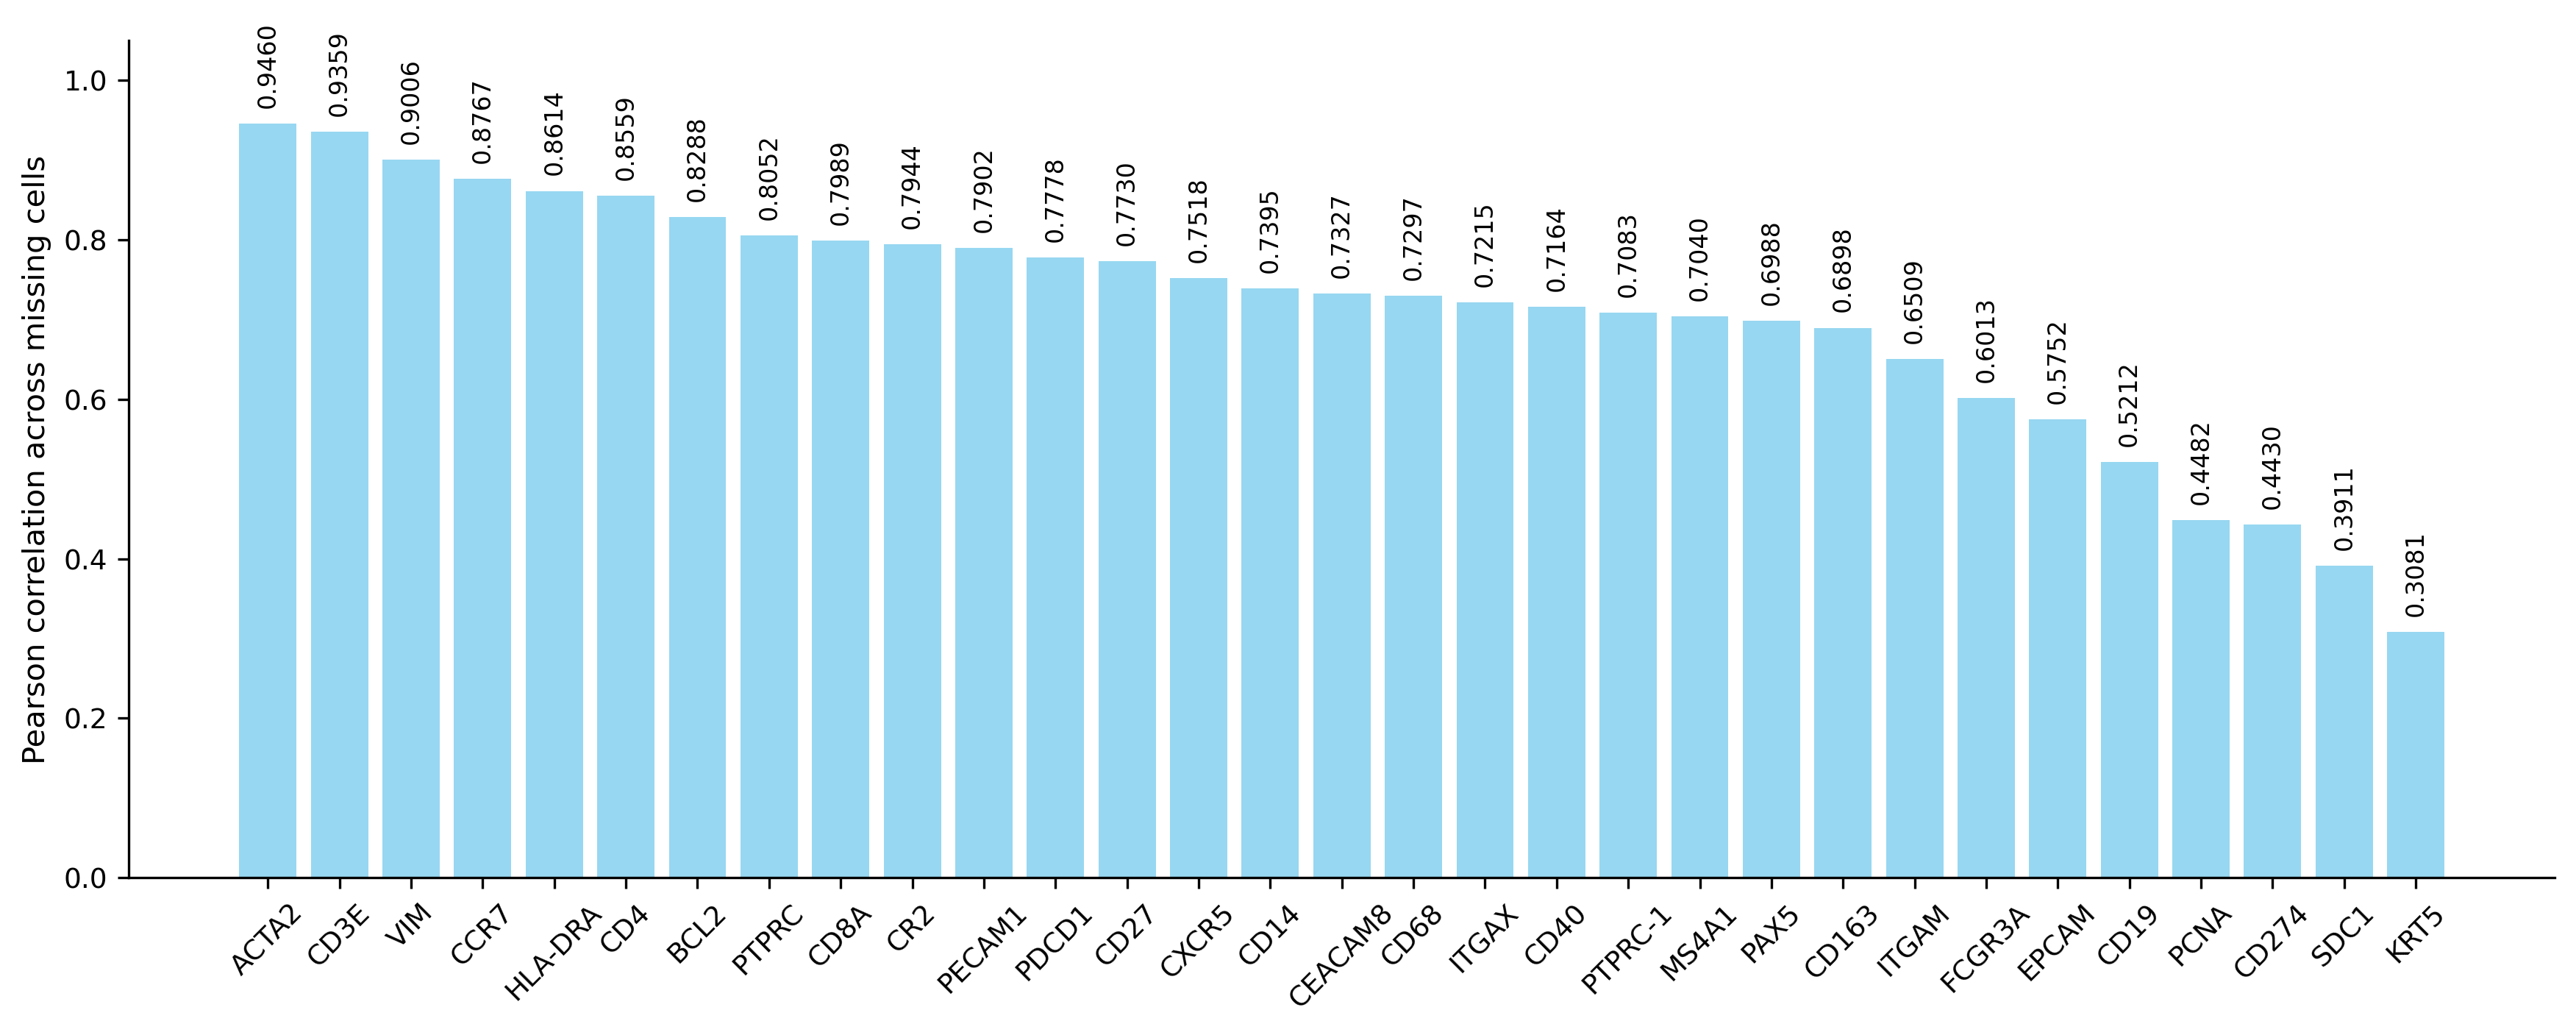

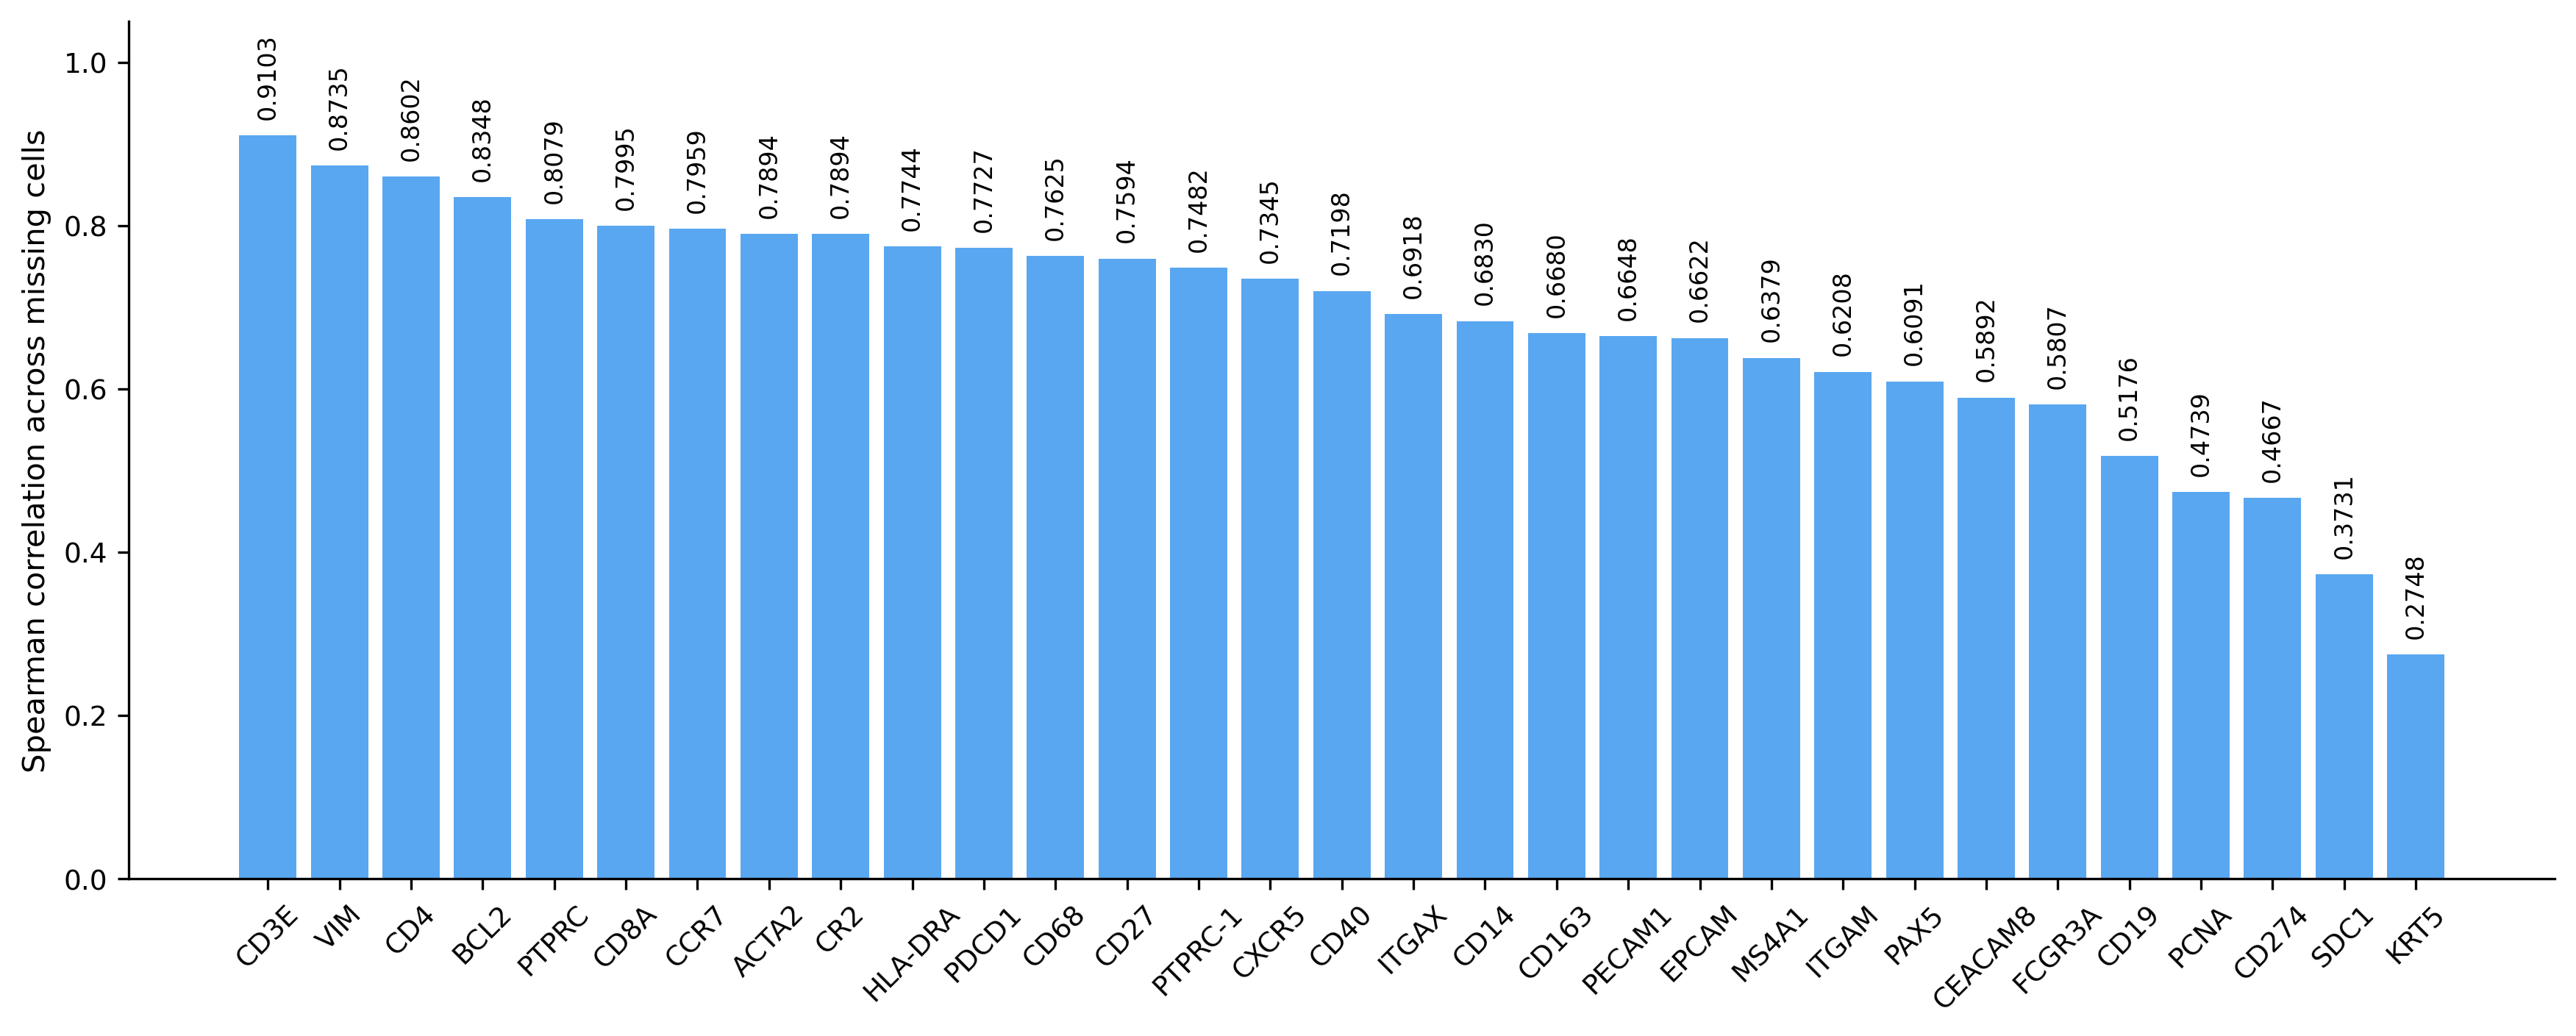

In [9]:
# Task 2: ADT imputation
# Evaluate ADT overall imputation performance in the simulated random incomplete registration
imputation_results = prism_eval_and_save(truth_adata=adata_target_out, adata=adata_target_out, 
                                         save_path=str(RESULTS_DIR), first_name=RUN_PREFIX,
                                         missing_indices=missing_indices,
                                         save_files=True)

# Visualize per-protein PCC and SPCC across missing cells
per_protein_figures = plot_per_protein_correlations(imputation_results, feature_names=adata_target.var_names)

Representative ADT protein CD3E: {'PCC': 0.9359, 'SPCC': 0.9103, 'MSE': 0.0031}


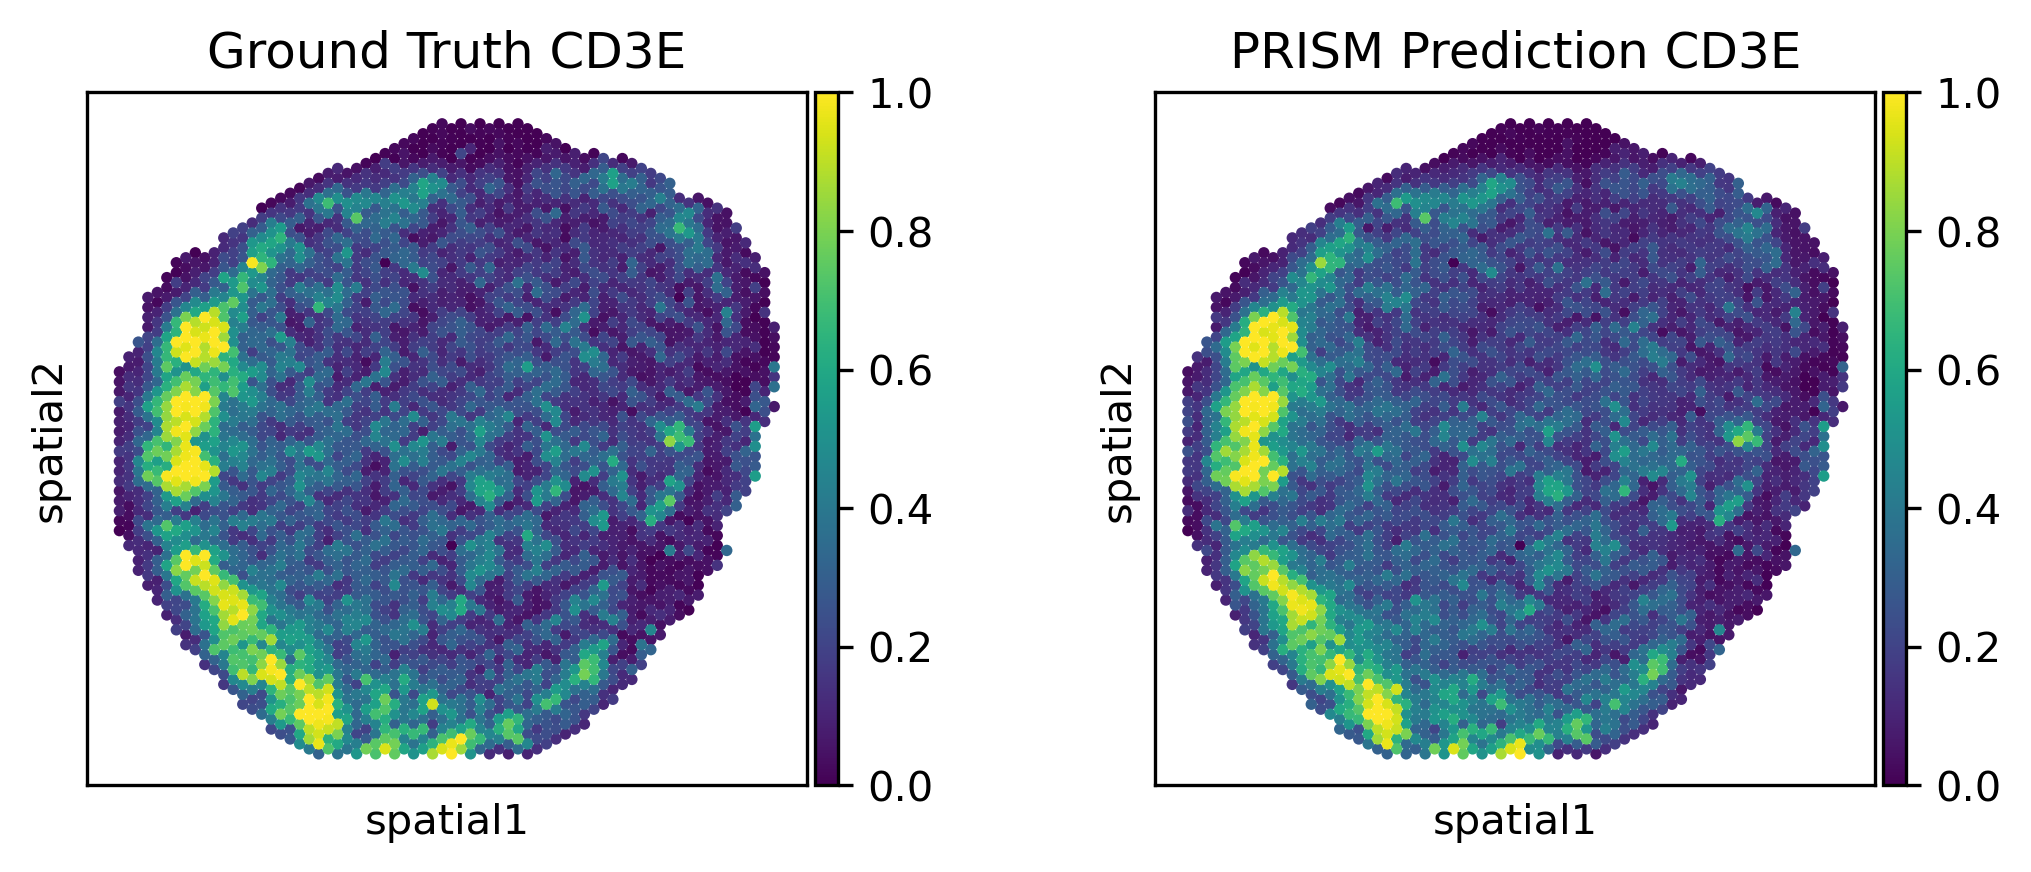

In [ ]:
#  Visualize Representative ADT feature
FEATURE_TO_PLOT = "CD3E"

fig, axs = plot_prism_imputation_spatial(imputation_results=imputation_results, split1_indices=missing_indices,
                                         feature=FEATURE_TO_PLOT, point_size=30, show_missing_only=False, highlight_missing=False,
                                         figsize=(8, 3))

feature_idx = adata_target.var_names.get_loc(FEATURE_TO_PLOT)
feature_metrics = {metric: round(float(imputation_results["raw"]["per_protein"][metric][feature_idx]), 4)
                   for metric in ("PCC", "SPCC", "MSE")}
print(f"Representative ADT protein {FEATURE_TO_PLOT}: {feature_metrics}")